# WFS controls for operation at ALS beamline 5.3.1

Authors: khchan@lbl.gov, francisho@lbl.gov, awojdyla@lbl.gov, walangrizolli@lbl.gov

We added capture of the beam a the sample. It doesn't quite work but we're close.
We want to acquire a nice grid scanbender/energy without any binning.

We want to add relevant metadata (exposure time , pixel size/camera model, binning) so that we can scale data accordingly (effective flux, effective size)

# SETUP 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tiled.client import from_uri

import wfs_live as wfl

## Setting up epics/ophyd/bluesky/tiled

In [2]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)

# here is the wrapper
#from h01 import mono_energy

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_bend_um.LLM', name='bender_um_low_limit_travel', parent='bender_um', timestamp=1781114676.579056, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_bend_um.LLM', limits=False, put_complete=False), done=False, success=False)

In [3]:
import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

In [4]:
mono_energy = MonoEnergy('', name='mono_energy')  # Empty prefix since motor has full PV

In [ ]:
BASLER_FILES_ROOT = "/mnt/data531"
BASLER_5472_IMAGE_DIR = "scans/%Y/%m/%d/basler5472"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs
BASLER_2448_IMAGE_DIR = "scans/%Y/%m/%d/basler2448"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs

try:
    basler_5472 = BaslerDetector(
        "BL531acA5427:",
        name="basler_5472",
        image_dir=BASLER_5472_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_5472.cam.stage_sigs['image_mode']    = 'Single'
    basler_5472.cam.stage_sigs['num_images']    = 1
    basler_5472.cam.stage_sigs['acquire_time']  = 2
    basler_5472.cam.stage_sigs['acquire_period'] = 0.5

    basler_5472.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_5472.tiff.stage_sigs['enable']        = 1
    basler_5472.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_5472.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_5472.read_attrs      = ['tiff']
    basler_5472.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

try:
    basler_2448 = BaslerDetector(
        "BL531a2A2448:",
        name="basler_2448",
        image_dir=BASLER_2448_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_2448.cam.stage_sigs['image_mode']    = 'Single'
    basler_2448.cam.stage_sigs['num_images']    = 1
    basler_2448.cam.stage_sigs['acquire_time']  = 1
    basler_2448.cam.stage_sigs['acquire_period'] = 1.1
    # basler_2448.cam.stage_sigs['trigger_mode'] = 'Off' 
    basler_2448.cam.stage_sigs['array_callbacks'] = 1
    # basler_2448.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    # basler_2448.tiff.stage_sigs['enable']        = 1
    # basler_2448.tiff.stage_sigs['auto_save']     = 'Yes'
    # basler_2448.tiff.stage_sigs['file_write_mode'] = 'Single'
    
    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    # basler_2448.read_attrs      = ['tiff']
    # basler_2448.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531a2A2448:'")

Error instantiating Basler camera: Failed to connect to all signals: basler_5472_cam.cam.gain (BL531acA5427:cam1:Gain), basler_5472_cam.cam.pixel_format (BL531acA5427:cam1:PixelFormat), basler_5472_cam.cam.exposure_auto (BL531acA5427:cam1:ExposureAuto), basler_5472_cam.cam.gain_auto (BL531acA5427:cam1:GainAuto), basler_5472_cam.cam.acquire_rbv (BL531acA5427:cam1:Acquire_RBV)
Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'
Basler camera connected successfully.


CA.Client.Exception...............................................
    Context: "192.168.10.124:46763"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Wed Jun 10 2026 11:49:47.243675990
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:37947"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Wed Jun 10 2026 11:49:50.363672874
..................................................................
modules/ca/src/client/udpiiu.cpp: Undecipherable (payload too small) UDP msg from 127.0.0.1:48685 ignored
modules/ca/src/client/udpiiu.cpp: Undecipherable (payload too small) UDP msg from 127.0.0.1:48685 ignored
CA.Client.Exception...............................................
    Context: "192.168.10.124:41683"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Thu Jun 11 2026 09:45:43.788846199
...............

In [6]:
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.001,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

linear stage position is 14.000361 mm
Linear motor position : 14.000361 mm
Rotary motor position : 0.0 deg
BCSMotor(name='bcs_linear_motor', motor_id='Galil x.20 A', position=14.0004 mm)
BCSMotor(name='bcs_rotary_motor', motor_id='Galil x.20 B', position=0.0000 mm)


In [7]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
## doesnt work yet because the central server is not configured to accept the resource documents with the local file paths. need to patch the resource documents to replace the local path prefix with the central path prefix before sending to central tiled server.

central_tiled_api_key = os.getenv("CENTRAL_API_KEY")
if not central_tiled_api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)


LOCAL_PATH_PREFIX = "mnt/data531"
CENTRAL_PATH_PREFIX = "/global/beegfs/beamlines/bl531/raw"

def patch_ride_filenames(doc: dict):
    """
    a TiledWriter will be sending documents to the central Tiled server.
    For resource documents, we want to patch resource_path;
    Add CENTRAL_PATH_PREFIX in place of LOCAL_PATH_PREFIX as the root key
    Strip LOCAL_PATH_PREFIX from the beginning of resource_path, if it exists
    :param doc_name: Description
    :type doc_name: str
    :param doc: Description
    :type doc: dict
    """    
    resource_path = doc.get("resource_path", "")
    if resource_path.startswith(LOCAL_PATH_PREFIX):
        # Strip LOCAL_PATH_PREFIX and prepend CENTRAL_PATH_PREFIX
        relative_path = resource_path[len(LOCAL_PATH_PREFIX):].lstrip("/")
        new_resource_path = os.path.join(CENTRAL_PATH_PREFIX, relative_path)
        doc["resource_path"] = new_resource_path
        #print(f"Patched resource_path: {resource_path} -> {new_resource_path}")
    return doc

central_tiled_writer = TiledWriter(central_tiled_client, batch_size=1, patches={"resource": patch_ride_filenames})
# uncomment this to connect to central tiled server
# RE.subscribe(central_tiled_writer)

RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)
sd.baseline = []
if sd:
#    sd.baseline = [mono_energy, Obender, bcs_linear_motor, basler_5472.cam.stage_sigs['acquire_time']] #for now just adding these two. add more as needed.
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] #for now just adding these two. add more as needed.


[BCSMotor] bcs_linear_motor: moving to 0.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 0.0000 mm
[BCSMotor] bcs_linear_motor: moving to 0.4000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 0.4000 mm
[BCSMotor] bcs_linear_motor: moving to 0.8000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 0.8000 mm
[BCSMotor] bcs_linear_motor: moving to 1.2000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 1.2000 mm
[BCSMotor] bcs_linear_motor: moving to 1.6000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 1.6000 mm
[BCSMotor] bcs_linear_motor: moving to 2.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 2.0000 mm
[BCSMotor] bcs_linear_motor: moving to 2.4000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 2.4000 mm
[BCSMotor] bcs_linear_motor: moving to 2.8000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 2.8000 mm
[BCSMotor] bcs_linear_motor: moving to 3.2000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 3.2000 mm
[

## Check data acquisition

In [13]:
from bluesky import plans as bp
sd.baseline = [mono_energy, Obender, bcs_linear_motor]

# cam_model = basler_5472.cam.model.read()['basler_5472_cam_model']['value']
objective_model = "Mitutoyo Plan Apo HR 5X"
# exp_time_s = basler_5472.cam.stage_sigs['acquire_time']
pixel_size_um = 2.4
binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
objective_mag = 5
effective_pixel_size_um = pixel_size_um * binx / objective_mag

# md={"exposure time [s]": f"{exp_time_s}", 
#     "pixel size [um]": f"{pixel_size_um}", 
#     "binning": f"{binx}x{biny}", 
#     "effective pixel size [um]": f"{effective_pixel_size_um}", 
#     "camera model": f"{cam_model}", 
#     "objective model": f"{objective_model}"
# }
md = {
    'pixel size [um]': f"{pixel_size_um}", 
    'binning': f"{binx}x{biny}",
    'effective pixel size [um]': f"{effective_pixel_size_um}", 
    'objective model': f"{objective_model}",   
}

uid = RE(bp.count([basler_5472], num=1, md = md))



Transient Scan ID: 2     Time: 2026-06-02 15:06:25
Persistent Unique Scan ID: '501d9861-7360-46ee-b9f1-a764a2292c0d'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 5002.014422330781              |
|         mono_energy_mono_angle | 29.731                         |
|                      bender_um | -1199.99208                    |
|               bcs_linear_motor | 14.000361                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 15:06:28.9 |
+-----------+------------+
generator count ['501d9861'] (scan num: 2)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 5002.014422330781              |
|         mono_energy_mono_angle | 29.731           

In [14]:
db = tiled_client[uid]

# Metadata: Hardware-reported; stored in config
cam   = db['primary'].metadata['configuration']['basler_5472']['data']
exp_time_s   = cam['basler_5472_cam_acquire_time']
camera_model = cam['basler_5472_cam_model']

# Descriptive (from md; .get())
start = db.metadata['start']
pixel_size_um           = start.get('pixel size [um]')
binning                 = start.get('binning')
effective_pixel_size_um = start.get('effective pixel size [um]')
objective_model         = start.get('objective model')

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning})")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")

Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm  (binning: 1x1)
Effective pixel: 0.48 µm
Exposure time:   2.0 s


In [15]:
# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")


WFS chip position (mm): [14.000361 14.000361]
Mono energy (eV): [5002.01442233 5002.01442233]
Bender position (µm): [-1199.99208 -1199.99208]

Images shape: (1, 3672, 1200)  (n_frames × height × width)


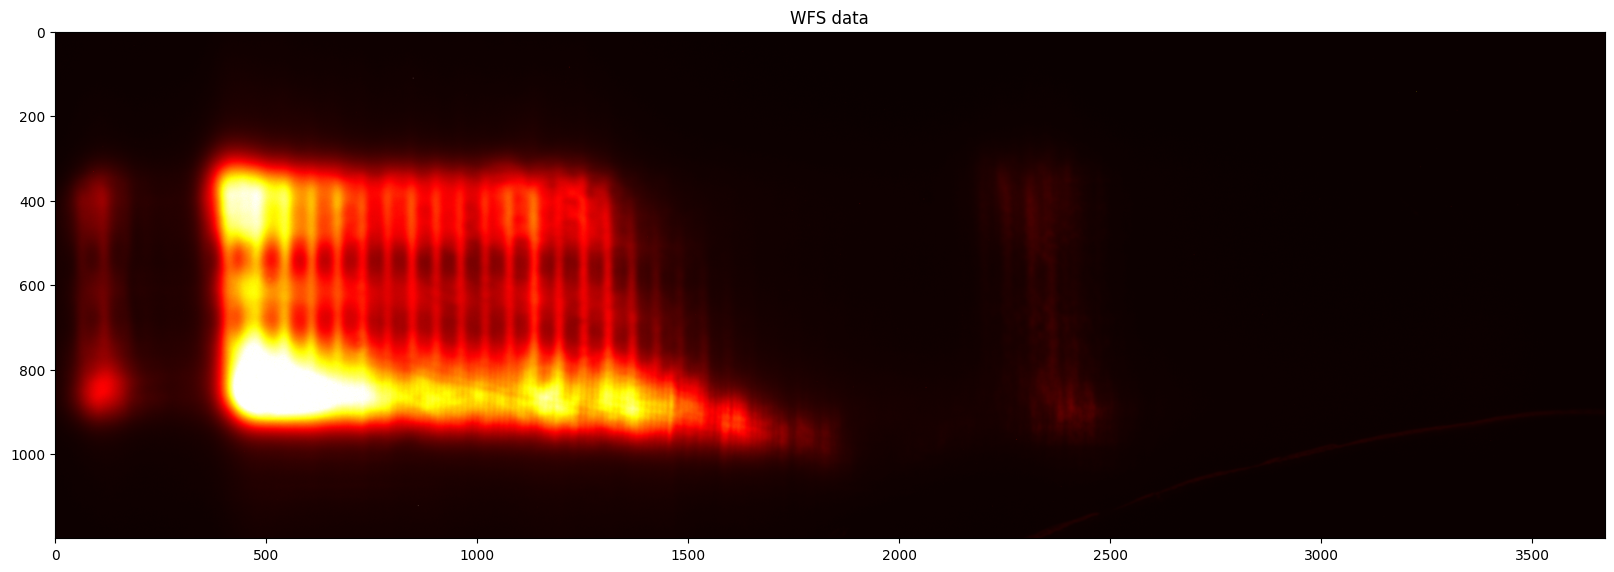

In [20]:
plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :].T, cmap='hot', clim=(0,4096))
plt.title('WFS data')
plt.show()

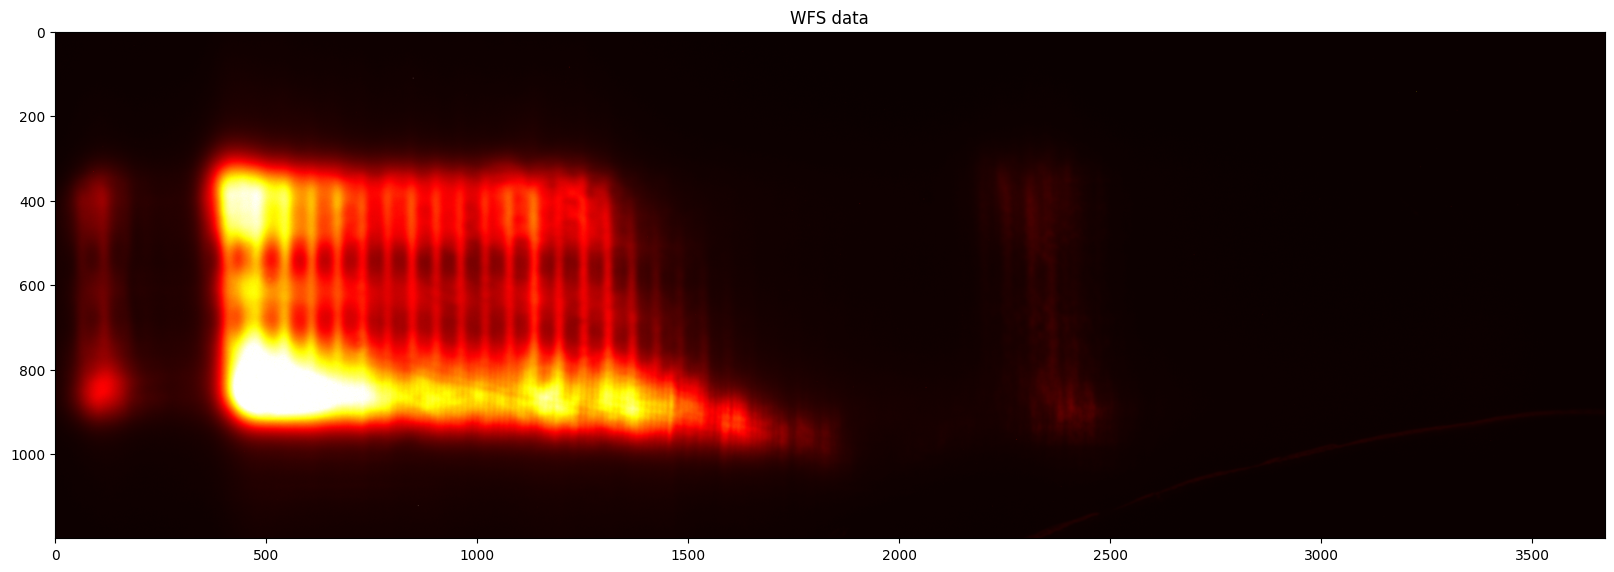

In [21]:
plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :].T, cmap='hot')
plt.title('WFS data')
plt.show()

# SCANS

## Trials


### Count

In [25]:
uid = RE(bp.count([basler_5472], num=1, md = md))



Transient Scan ID: 4     Time: 2026-05-29 18:08:20
Persistent Unique Scan ID: '31975a86-8951-43c4-bb22-d4d3617a5ff2'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8001.278945132818              |
|         mono_energy_mono_angle | 20.753                         |
|                      bender_um | -1999.98627                    |
|               bcs_linear_motor | 4.399955                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 18:08:23.6 |
+-----------+------------+
generator count ['31975a86'] (scan num: 4)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8001.278945132818              |
|         mono_energy_mono_angle | 20.753           

### Energy and bender scans

In [22]:
uid_01 = RE(bp.scan([basler_5472], mono_energy, 5000, 8500, 11))



Transient Scan ID: 3     Time: 2026-06-02 15:08:02
Persistent Unique Scan ID: '16b51b82-529f-4bb0-858d-b8b4539685dd'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 5002.014422330781              |
|         mono_energy_mono_angle | 29.731                         |
|                      bender_um | -1199.99208                    |
|               bcs_linear_motor | 14.000361                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 15:08:05.6 |              4999.987 |                29.7410 |
|         2 | 15:08:10.7 |              5349.863 |                28.1370 |
|         3 | 15

In [23]:
db = tiled_client[uid_01]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")


WFS chip position (mm): [14.000361 14.000361]

Images shape: (11, 3672, 1200)  (n_frames × height × width)
Energy range: 5000.0 – 8500.1 eV
       shape: (11,)


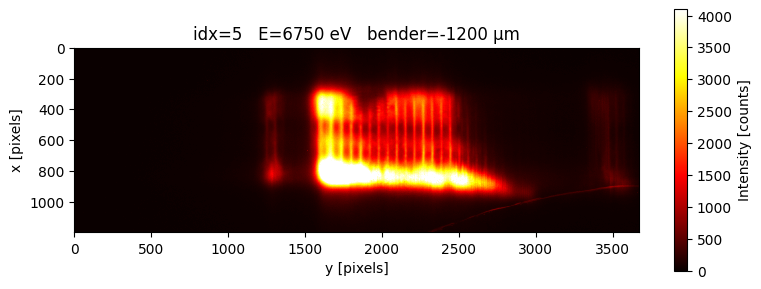

In [26]:
idx = 5

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4096)
plt.title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[0]:.0f} µm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [31]:
mono_energy.move(5000)
Obender.move(-1200)

MoveStatus(done=True, pos=bender_um, elapsed=2.2, success=True, settle_time=0.0)

In [28]:
print(mono_energy.get())
print(Obender.get())
print(bcs_linear_motor.get())

MonoEnergyTuple(energy_eV=PseudoSingleTuple(readback=np.float64(4999.986855283759), setpoint=5000), mono_angle=EpicsMotorTuple(user_readback=29.741, user_setpoint=29.74093514146466, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=1.0, acceleration=0.2, motor_egu='deg', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=180.0, low_limit_travel=-100.0, direction_of_travel=0, motor_stop=0, home_forward=0, home_reverse=0), offset=np.float64(6.444797761216426))
EpicsMotorTuple(user_readback=-1199.99208, user_setpoint=-1200.0, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=100.0, acceleration=0.2, motor_egu='um', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=5000.0, low_limit_travel=-2000.0, direction_of_travel=1, motor_stop=0, home_forward=0, home_reverse=0)
14.000361


### Chip translation scan

In [32]:
uid_01 = RE(bp.scan([basler_5472], bcs_linear_motor, 0, 20, 51))



Transient Scan ID: 4     Time: 2026-06-02 15:12:20
Persistent Unique Scan ID: 'f44ee8e2-9904-42df-9eb4-ca4c273bacd0'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 4999.986855283759              |
|         mono_energy_mono_angle | 29.741                         |
|                      bender_um | -1199.99208                    |
|               bcs_linear_motor | 14.000361                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+------------------+
|   seq_num |       time | bcs_linear_motor |
+-----------+------------+------------------+
|         1 | 15:12:30.8 |            0.000 |
|         2 | 15:12:36.5 |            0.400 |
|         3 | 15:12:42.1 |            0.800 |
|         4 | 15:12:47.6 |            1.200 |
|         5 | 15:12:53.2 |            1.600 |
|         6 | 15:12:58.9 |  

In [34]:
db = tiled_client[uid_01]

# Metadata
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

# print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
print(f"       shape: {wfs_chip_pos_mm.shape}")

Mono energy (eV): [4999.98685528 4999.98685528]
Bender position (µm): [-1199.99208 -1199.99208]

Images shape: (51, 3672, 1200)  (n_frames × height × width)
WFS chip position range: 0.000 – 20.000 mm
       shape: (51,)


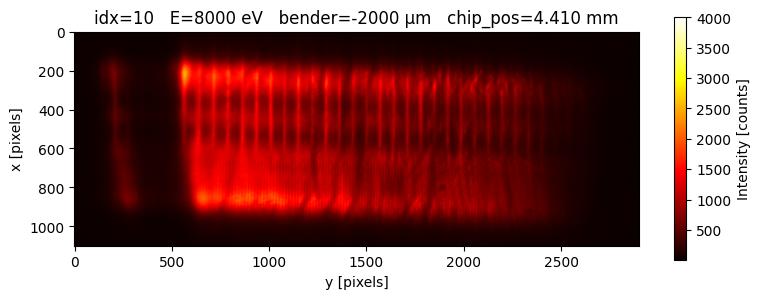

In [48]:
idx = 10

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[idx]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

### Grid scan

In [ ]:
from bluesky.plans import grid_scan

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_04 = RE(grid_scan([basler_5472], mono_energy, 7500, 8500, 3, Obender, -2000, -1400, 4, snake_axes=False, md=md))  

Energy setpoint: 8000.0 eV (readback: 8000.0 eV)
Bender setpoint: -2000 µm (readback: -2000 µm)
BCS linear motor: 4.410 mm


Transient Scan ID: 8     Time: 2026-05-29 18:31:41
Persistent Unique Scan ID: '19792fc0-a08c-46d6-89a4-a7a2cd138c5d'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755                         |
|                      bender_um | -1999.98786                    |
|               bcs_linear_motor | 4.409976                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |  bender_um |
+-----------+------------+-----------------------+------------------------+------------+
|     

In [58]:
db = tiled_client[uid_04]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
# bender_um = db['baseline']['bender_um'].read()
# energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
# print(f"Mono energy (eV): {energy_eV}")
# print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

WFS chip position (mm): [4.409976 4.409976]

Images shape: (12, 2900, 1100)  (n_frames × height × width)
Energy range: 7499.9 – 8500.1 eV
       shape: (12,)
Bender range: -2000.0 – -1400.0 µm
       shape: (12,)


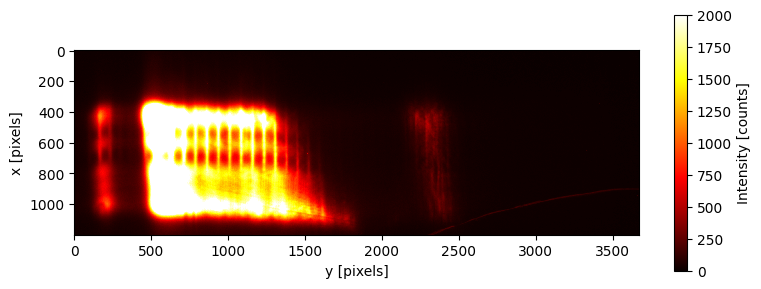

In [43]:
idx = 16

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=2000)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

## Measurements



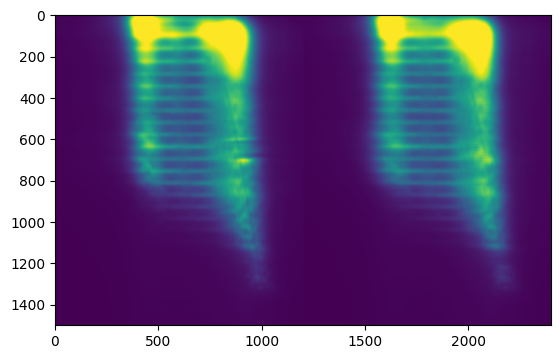

CA.Client.Exception...............................................
    Context: "192.168.10.124:40543"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Jun 02 2026 15:26:03.066845632
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:42231"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Wed Jun 03 2026 09:21:29.560304622
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:35399"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Wed Jun 03 2026 13:43:37.845568108
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:37567"
    Source File: modules/ca/src/client/cac.cpp line 1237


In [57]:
plt.imshow(np.concatenate((images[31,500:2000], images[32,500:2000]), axis=1))